#Fake News Detection Using NLP

##Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

##Load Dataset

In [3]:
fake = pd.read_csv("Fake.csv")
real = pd.read_csv("True.csv")
fake.head()
real.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


##Create Labels

In [4]:
fake["label"] = 0
real["label"] = 1

##Merge Datasets

In [8]:
df = pd.concat([fake, real])

df.head()


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [9]:
df.shape

(44898, 5)

##Keep Required Columns

In [10]:
df = df[["text","label"]]

##Check Missing Values

In [11]:
df.isnull().sum()
df.dropna(inplace=True)

##NLP Preprocessing

In [12]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

##Clean Text

In [13]:
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [14]:
df["text"] = df["text"].apply(clean_text)

##Convert Text to Numbers (TF-IDF)

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df["text"])

y = df["label"]

##Split Dataset

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

##Train Logistic Regression

In [17]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

##Train Naive Bayes

In [18]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

##Train Random Forest

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

##Compare Models

In [20]:
from sklearn.metrics import accuracy_score

print("Logistic Regression:",
      accuracy_score(y_test, lr_pred))

print("Naive Bayes:",
      accuracy_score(y_test, nb_pred))

print("Random Forest:",
      accuracy_score(y_test, rf_pred))

Logistic Regression: 0.9879732739420936
Naive Bayes: 0.9300668151447662
Random Forest: 0.9976614699331848


In [22]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

results.sort_values(
    by="Accuracy",
    ascending=False,
    inplace=True
)

print(results)

                 Model  Accuracy
2        Random Forest  0.997661
0  Logistic Regression  0.987973
1          Naive Bayes  0.930067


##Plot Accuracy Graph

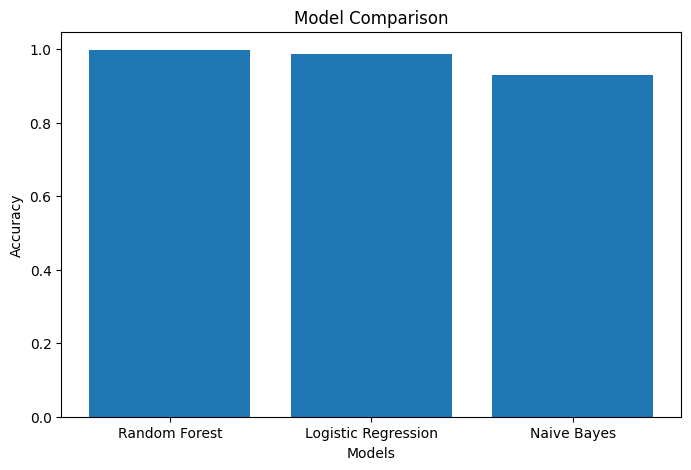

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

##Classification Report

In [25]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4733
           1       1.00      1.00      1.00      4247

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



##Confusion Matrix

In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    rf_pred
)

print(cm)

[[4720   13]
 [   8 4239]]


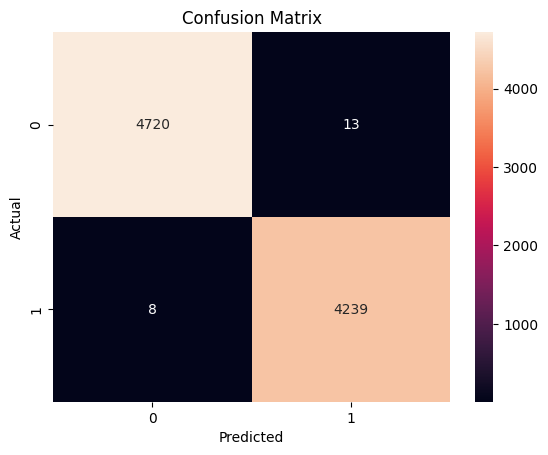

In [27]:
import seaborn as sns

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

##Save Best Model

In [28]:
import pickle

pickle.dump(
    rf,
    open("fake_news_model.pkl","wb")
)

pickle.dump(
    vectorizer,
    open("tfidf.pkl","wb")
)

print("Model Saved Successfully!")

Model Saved Successfully!


##Test News Prediction

In [29]:
sample_news = [
    "Government launches a new education policy for engineering students."
]

sample_vector = vectorizer.transform(sample_news)

prediction = rf.predict(sample_vector)

if prediction[0] == 1:
    print("REAL NEWS")
else:
    print("FAKE NEWS")

FAKE NEWS


##Save the TF-IDF Vectorizer

In [31]:
import pickle

pickle.dump(
    vectorizer,
    open("tfidf.pkl","wb")
)

print("TF-IDF Saved")

TF-IDF Saved
